In [61]:
import pandas as pd
import matplotlib.pyplot as plt

In [62]:
df = pd.read_csv("Apple_Stock.csv")

In [63]:
df.head()

,Date,Close/Last,Volume,Open,High,Low
0,02/28/2020,$273.36,106721200,$257.26,$278.41,$256.37
1,02/27/2020,$273.52,80151380,$281.1,$286,$272.96
2,02/26/2020,$292.65,49678430,$286.53,$297.88,$286.5
3,02/25/2020,$288.08,57668360,$300.95,$302.53,$286.13
4,02/24/2020,$298.18,55548830,$297.26,$304.18,$289.23


In [64]:
df.drop([' Volume', ' Open', ' High', ' Low'], axis=1, inplace=True)
df.head()

,Date,Close/Last
0,02/28/2020,$273.36
1,02/27/2020,$273.52
2,02/26/2020,$292.65
3,02/25/2020,$288.08
4,02/24/2020,$298.18


In [65]:
df.columns = df.columns.str.strip()
df.columns

Index(['Date', 'Close/Last'], dtype='object')

In [66]:
df.head()

,Date,Close/Last
0,02/28/2020,$273.36
1,02/27/2020,$273.52
2,02/26/2020,$292.65
3,02/25/2020,$288.08
4,02/24/2020,$298.18


In [67]:
df['Close/Last'] = df['Close/Last'].replace('[\$,]', '', regex=True).astype(float)

<>:1: SyntaxWarning: invalid escape sequence '\$'
<>:1: SyntaxWarning: invalid escape sequence '\$'
C:\Users\admin\AppData\Local\Temp\ipykernel_14080\2548826300.py:1: SyntaxWarning: invalid escape sequence '\$'
  df['Close/Last'] = df['Close/Last'].replace('[\$,]', '', regex=True).astype(float)


In [68]:
df.head()

,Date,Close/Last
0,02/28/2020,273.36
1,02/27/2020,273.52
2,02/26/2020,292.65
3,02/25/2020,288.08
4,02/24/2020,298.18


In [69]:
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values(by='Date')

In [70]:
df.set_index('Date', inplace=True)

In [71]:
df.head()

,Close/Last
Date,
2010-03-01,29.8557
2010-03-02,29.8357
2010-03-03,29.9043
2010-03-04,30.1014
2010-03-05,31.2786


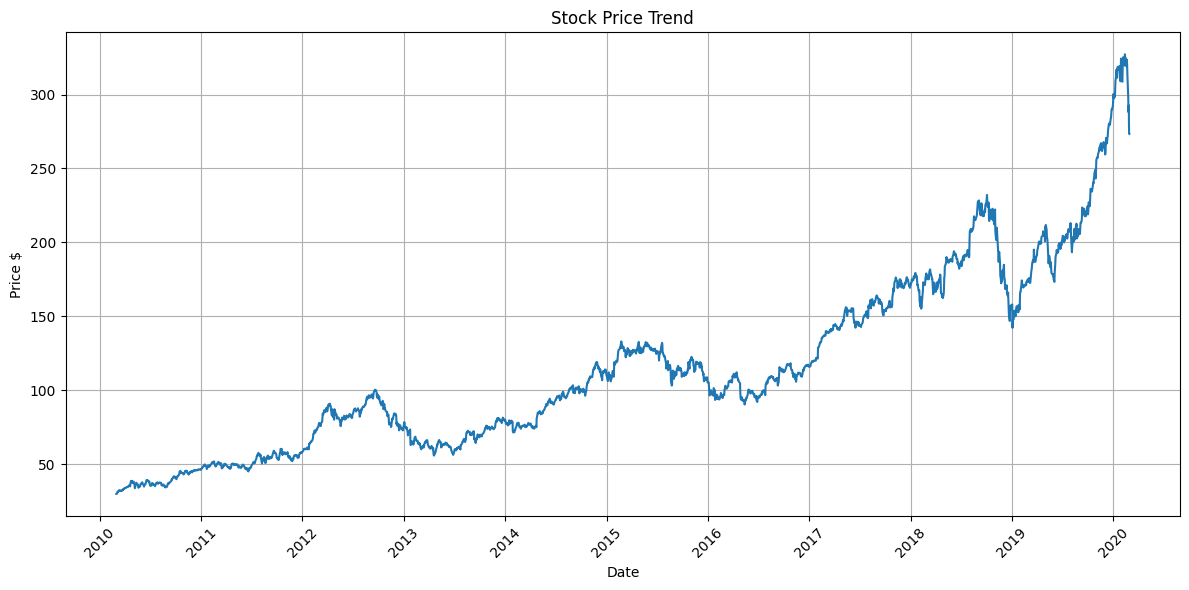

In [72]:
plt.figure(figsize=(12,6))
plt.plot(df.index, df['Close/Last'])
plt.title('Stock Price Trend')
plt.xlabel('Date')
plt.ylabel('Price $')
plt.grid()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [73]:
import numpy as np
from statsmodels.tsa.seasonal import seasonal_decompose

In [74]:
# Diffence the data to make it stationary
df['price_diff'] = df['Close/Last'].diff()
df.head()

,Close/Last,price_diff
Date,,
2010-03-01,29.8557,NaN
2010-03-02,29.8357,-0.0200
2010-03-03,29.9043,0.0686
2010-03-04,30.1014,0.1971
2010-03-05,31.2786,1.1772


In [75]:
# By using sesonal Decomposition
result = seasonal_decompose(df['Close/Last'], model='additive', period=12)
df['price_s_diff'] = result.resid
df.head(10)

,Close/Last,price_diff,price_s_diff
Date,,,
2010-03-01,29.8557,NaN,NaN
2010-03-02,29.8357,-0.0200,NaN
2010-03-03,29.9043,0.0686,NaN
2010-03-04,30.1014,0.1971,NaN
2010-03-05,31.2786,1.1772,NaN
2010-03-08,31.2971,0.0185,NaN
2010-03-09,31.8600,0.5629,0.306178
2010-03-10,32.1200,0.2600,0.391350
2010-03-11,32.2143,0.0943,0.462722


In [76]:
# By using log transformation
df['price_log'] = np.log(df['Close/Last'])
df['price_log_diff'] = np.log(df['Close/Last']).diff()
df.head(10)

,Close/Last,price_diff,price_s_diff,price_log,price_log_diff
Date,,,,,
2010-03-01,29.8557,NaN,NaN,3.396376,NaN
2010-03-02,29.8357,-0.0200,NaN,3.395706,-0.000670
2010-03-03,29.9043,0.0686,NaN,3.398002,0.002297
2010-03-04,30.1014,0.1971,NaN,3.404572,0.006569
2010-03-05,31.2786,1.1772,NaN,3.442934,0.038362
2010-03-08,31.2971,0.0185,NaN,3.443525,0.000591
2010-03-09,31.8600,0.5629,0.306178,3.461351,0.017826
2010-03-10,32.1200,0.2600,0.391350,3.469479,0.008128
2010-03-11,32.2143,0.0943,0.462722,3.472410,0.002932


In [77]:
# By using log seasonal decomposition
result = seasonal_decompose(df['price_log_diff'].dropna(), model='additive', period=12)
df['price_log_s_diff'] = result.resid
df.head(10)

,Close/Last,price_diff,price_s_diff,price_log,price_log_diff,price_log_s_diff
Date,,,,,,
2010-03-01,29.8557,NaN,NaN,3.396376,NaN,NaN
2010-03-02,29.8357,-0.0200,NaN,3.395706,-0.000670,NaN
2010-03-03,29.9043,0.0686,NaN,3.398002,0.002297,NaN
2010-03-04,30.1014,0.1971,NaN,3.404572,0.006569,NaN
2010-03-05,31.2786,1.1772,NaN,3.442934,0.038362,NaN
2010-03-08,31.2971,0.0185,NaN,3.443525,0.000591,NaN
2010-03-09,31.8600,0.5629,0.306178,3.461351,0.017826,NaN
2010-03-10,32.1200,0.2600,0.391350,3.469479,0.008128,0.002106
2010-03-11,32.2143,0.0943,0.462722,3.472410,0.002932,-0.000498


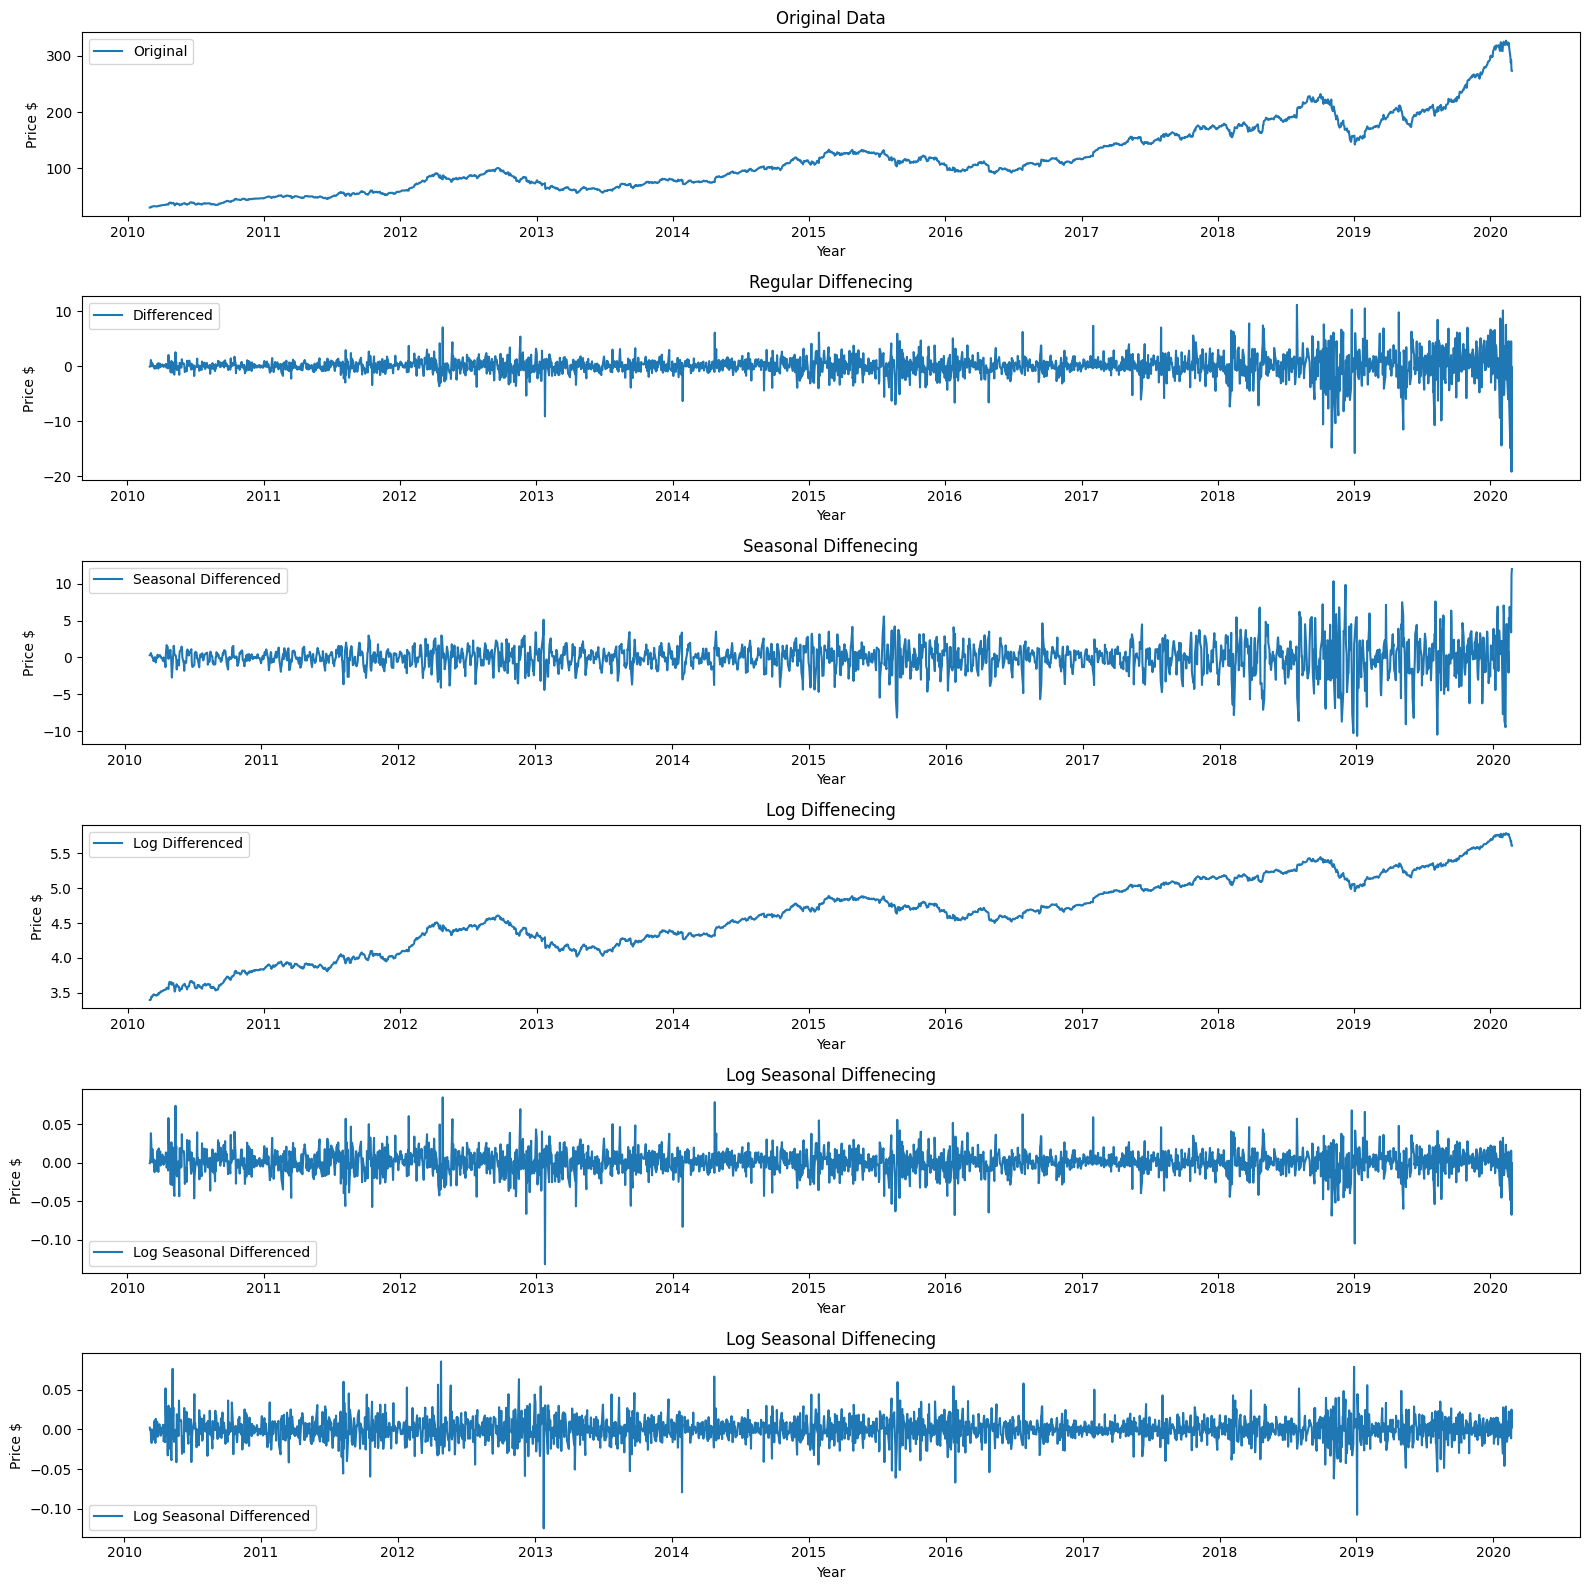

In [78]:
plt.figure(figsize=(16,16))

plt.subplot(6,1,1)
plt.plot(df['Close/Last'],label='Original')
plt.legend(loc='best')
plt.title('Original Data')
plt.xlabel('Year')
plt.ylabel('Price $')

plt.subplot(6,1,2)
plt.plot(df['price_diff'],label='Differenced')
plt.legend(loc='best')
plt.title('Regular Diffenecing')
plt.xlabel('Year')
plt.ylabel('Price $')

plt.subplot(6,1,3)
plt.plot(df['price_s_diff'],label='Seasonal Differenced')
plt.legend(loc='best')
plt.title('Seasonal Diffenecing')
plt.xlabel('Year')
plt.ylabel('Price $')

plt.subplot(6,1,4)
plt.plot(df['price_log'],label='Log Differenced')
plt.legend(loc='best')
plt.title('Log Diffenecing')
plt.xlabel('Year')
plt.ylabel('Price $')

plt.subplot(6,1,5)
plt.plot(df['price_log_diff'],label='Log Seasonal Differenced')
plt.legend(loc='best')
plt.title('Log Seasonal Diffenecing')
plt.xlabel('Year')
plt.ylabel('Price $')

plt.subplot(6,1,6)
plt.plot(df['price_log_s_diff'],label='Log Seasonal Differenced')
plt.legend(loc='best')
plt.title('Log Seasonal Diffenecing')
plt.xlabel('Year')
plt.ylabel('Price $')

plt.tight_layout()
plt.show()

<Axes: xlabel='Date'>

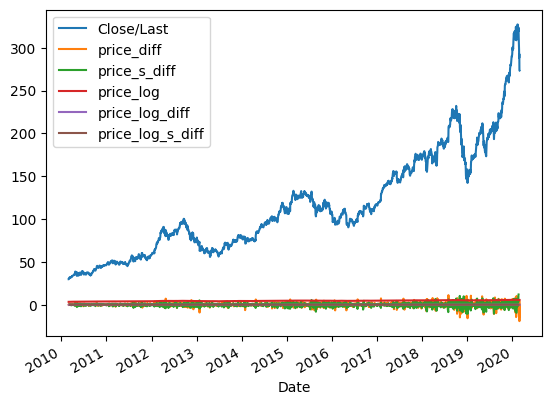

In [79]:
df.plot(kind='line')

In [80]:
resampled_data = df['Close/Last'].resample('Y').sum().to_frame()
resampled_data.head()

C:\Users\admin\AppData\Local\Temp\ipykernel_14080\3847420930.py:1: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  resampled_data = df['Close/Last'].resample('Y').sum().to_frame()


,Close/Last
Date,
2010-12-31,8250.9370
2011-12-31,13104.1513
2012-12-31,20573.1988
2013-12-31,17014.8484
2014-12-31,23250.6666


In [81]:
resampled_data.index = resampled_data.index.year
resampled_data.reset_index(inplace=True)
resampled_data.rename(columns={'Month': 'Year'}, inplace=True)
resampled_data.head()

,Date,Close/Last
0,2010,8250.9370
1,2011,13104.1513
2,2012,20573.1988
3,2013,17014.8484
4,2014,23250.6666


In [82]:
years = resampled_data['Date'].tolist()
passengers = resampled_data['Close/Last'].tolist()

In [83]:
# linear trend estimation
X = [i - years[len(years) // 2] for i in years]
x2 = [i ** 2 for i in X]
xy = [i * j for i, j in zip(X, passengers)]
n = len(years)
b = (n * sum(xy) - sum(passengers) * sum(X)) / (n * sum(x2) - (sum(X) ** 2))
a = (sum(passengers) - b * sum(X)) / n
linear_trend = [a + b * X[i] for i in range(n)]

In [84]:

# Polynomial Trend Estimation (Degree 2)
x3 = [i ** 3 for i in X]
x4 = [i ** 4 for i in X]
x2y = [i * j for i, j in zip(x2, passengers)]
coeff = [[len(X), sum(X), sum(x2)],
[sum(X), sum(x2), sum(x3)],
[sum(x2), sum(x3), sum(x4)]]
Y = [sum(passengers), sum(xy), sum(x2y)]
A = np.array(coeff)
B = np.array(Y)
solution = np.linalg.solve(A, B)
a_poly, b_poly, c_poly = solution
poly_trend = [a_poly + b_poly * X[i] + c_poly * (X[i] ** 2) for i in range(n)]

Linear Trend: y=26271.79 + 2762.42x

Polynomial Trend: y=31418.70 + 2762.42x + -514.69x²


<Axes: xlabel='Date'>

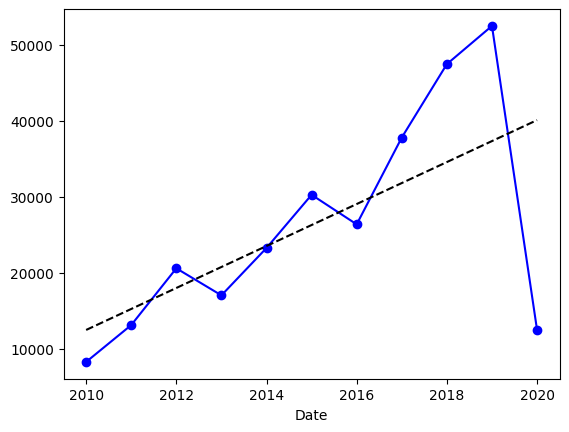

In [85]:
#Visualising results
print(f"Linear Trend: y={a:.2f} + {b:.2f}x")
print(f"\nPolynomial Trend: y={a_poly:.2f} + {b_poly:.2f}x + {c_poly:.2f}x²")
resampled_data['Linear Trend'] = linear_trend
resampled_data['Polynomial Trend'] = poly_trend
resampled_data.set_index('Date',inplace=True)
resampled_data['Close/Last'].plot(kind='line',color='blue',marker='o') #alpha=0.3 makes 
resampled_data['Linear Trend'].plot(kind='line',color='black',linestyle='--')

<Axes: xlabel='Date'>

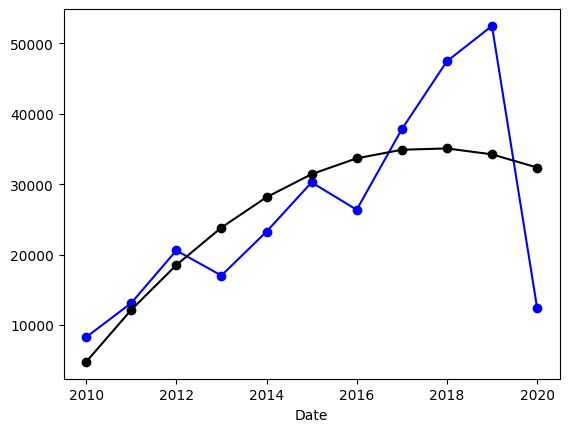

In [86]:
resampled_data['Close/Last'].plot(kind='line',color='blue',marker='o')
resampled_data['Polynomial Trend'].plot(kind='line',color='black',marker='o')